# NVDA market regimes and a reinforcement learning trader
## Unsupervised discovery of market states, used as the state space of an RL agent

- **Author:** Hussein Loubani
- **Dataset:** NVIDIA (NVDA) daily OHLCV from 2010 to today, via yfinance
- **Unsupervised task:** discover interpretable market regimes from returns and volatility
- **Reinforcement learning task:** learn a long / flat / short policy under transaction costs
- **Caveat up front:** a single asset over a single extraordinary bull run is a narrow test bed, and every result below should be read with that in mind

---

### Table of contents

1. Imports and setup
2. Problem definition
3. Data acquisition and first audit
4. Train / test split
5. Exploratory data analysis
6. Unsupervised learning: discovering market regimes
7. The reinforcement learning environment
8. Tabular agents: Q-learning and SARSA
9. Does the unsupervised layer help? An ablation
10. Final evaluation against baselines
11. Conclusion, limitations, and recommendations

---
## 1. Imports and setup

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from nvda_rl.config import (
    ACTIONS,
    N_REGIMES,
    RANDOM_SEED,
    SPLIT_DATE,
    TRANSACTION_COST,
)
from nvda_rl.dataset import (
    audit_prices,
    clean_prices,
    download_data,
    extreme_days,
    load_prices,
    split_prices,
)
from nvda_rl.features import (
    add_features,
    apply_binner,
    drop_warmup,
    fit_binner,
    regime_matrix,
)
from nvda_rl.modeling import regimes as rg
from nvda_rl.modeling.agents import (
    QLearningAgent,
    SarsaAgent,
    buy_and_hold_policy,
    flat_policy,
    random_policy_factory,
)
from nvda_rl.modeling.environment import TradingEnv
from nvda_rl.modeling.evaluate import (
    action_distribution,
    compare_policies,
    equity_curves,
    regime_action_map,
)
from nvda_rl.plots import (
    apply_global_style,
    plot_action_timeline,
    plot_anomalies,
    plot_equity_curves,
    plot_learning_curves,
    plot_metric_comparison,
    plot_policy_by_regime,
    plot_price_and_volume,
    plot_regime_projection,
    plot_regime_selection,
    plot_regime_timeline,
    plot_return_distribution,
    plot_rolling_sharpe,
    plot_transition_matrix,
    plot_volatility_and_drawdown,
    save_figure,
)

# No global warning filter: silencing everything would also hide the HMM and
# K-means convergence warnings that signal a model which never settled, and a
# regime label from an unconverged fit would quietly poison the agent's state.
apply_global_style()

RAW_DIR = Path.cwd().parent / "data" / "raw"
FIG_DIR = Path.cwd().parent / "reports" / "figures"

---
## 2. Problem definition

| Field | Value |
|---|---|
| **Asset** | NVIDIA (NVDA), daily bars, split and dividend adjusted |
| **Period** | 2010-01-01 to today |
| **Unsupervised goal** | group trading days into a few market regimes I can name |
| **RL goal** | pick a position in {-1 short, 0 flat, +1 long} each day |
| **Split** | chronological: train before 2021, test from 2021 on |

**The business question.** A trader already knows NVDA behaves differently in a calm advance than in a violent drawdown. But "differently" is not something you can trade. The unsupervised half turns that intuition into a label on every day. The RL half asks whether a policy that sees the label decides better than one that does not. That second answer is the actual deliverable.

**Why RL and not a return forecast.** A model predicting tomorrow's return optimizes accuracy, which is the wrong target. What matters is position sizing under costs, and that is sequential: the cost of being long tomorrow depends on whether I am long today. That dependence makes this an MDP, and it is why the current position sits inside the state.

| Element | Definition |
|---|---|
| **State** | binned volatility, momentum, distance from the 252-day high, optionally the regime label, plus the position held |
| **Action** | the position to hold into the next day |
| **Reward** | $r_t = a_{t-1} \cdot \text{return}_t - \text{cost} \cdot |a_t - a_{t-1}|$ |
| **Transition** | replay of the historical tape; only the position responds to the agent |
| **Discount** | 0.99, so positions are valued over weeks |

Read the reward twice. Yesterday's position earns today's return, not the one I pick now, so the agent cannot act on a return it has already seen. And the cost scales with how much the position moves, so a short-to-long flip costs twice a flat-to-long entry.

**Primary metric:** cumulative PnL against buy-and-hold. **Secondary:** annualized return, Sharpe, max drawdown, hit ratio, turnover. Turnover matters more than it looks, because it is what the cost multiplies.

---
## 3. Data acquisition and first audit

### 3.1 Download and load

In [2]:
download_data(RAW_DIR)          # skips the download when the cache exists
prices = load_prices(RAW_DIR)
prices.tail(3)

  NVDA cached (NVDA.csv)


,date,open,high,low,close,volume,return,log_return
4163,2026-07-24,207.449997,211.910004,204.809998,206.839996,114836800,-0.009197,-0.009240
4164,2026-07-27,208.199997,208.750000,195.440002,196.509995,153868500,-0.049942,-0.051232
4165,2026-07-28,194.949997,198.699997,192.740005,197.970001,76823195,0.007430,0.007402


In [3]:
audit_prices(prices)

,NVDA
rows,4166
first_date,2010-01-04
last_date,2026-07-28
duplicate_dates,0
missing_close,0
missing_volume,0
non_positive_close,0
max_gap_days,5
mean_daily_return_%,0.1884
daily_vol_%,2.864


### 3.2 Audit findings

The series is clean. No duplicate dates, no missing closes or volumes, no non-positive prices, and the largest calendar gap is five days, which is a long weekend rather than a hole. The download is cached to CSV, so reruns reproduce these numbers without touching the network.

One thing about the raw feed matters. Prices come split and dividend adjusted. NVDA split several times here, and unadjusted closes would show huge fake overnight losses on those dates. A regime model fed that would happily find a "crash" regime that is really a corporate action.

### 3.3 Cleaning and extreme days

In [4]:
prices = clean_prices(prices)
print(f"Rows after cleaning: {len(prices):,}")
extreme_days(prices, n=5)

Rows after cleaning: 4,165


,date,close,volume,kind,return_%
0,2016-11-11,2.160570,2175344000,largest gain,29.81
1,2023-05-25,37.902237,1543911000,largest gain,24.37
2,2025-04-09,114.170006,612918300,largest gain,18.72
3,2017-05-10,2.987143,2129096000,largest gain,17.83
4,2020-03-24,6.197947,1101644000,largest gain,17.16
5,2018-11-16,4.067513,1963520000,largest loss,-18.76
6,2020-03-16,4.885130,726972000,largest loss,-18.45
7,2025-01-27,118.243401,818830900,largest loss,-16.97
8,2019-01-28,3.417375,2511528000,largest loss,-13.82
9,2020-03-12,5.380358,816540000,largest loss,-12.24


These are real market history, not data errors, so nothing is trimmed. The biggest moves cluster around earnings and the 2020 and 2022 shocks. Those are exactly the days a regime model exists to find. Deleting them as outliers would remove the signal and leave a tidier world than the one that exists.

### 3.4 Feature construction

Every feature at day *t* uses information up to *t*'s close. The environment then pays day *t+1*'s return for a position taken at *t*. That ordering is what keeps look-ahead out of the pipeline.

In [5]:
featured = add_features(prices)
featured = drop_warmup(featured)
print(f"Rows after dropping the rolling-window warm-up: {len(featured):,}")
print(f"Date range: {featured['date'].min().date()} to {featured['date'].max().date()}")
featured[["date", "close", "return", "volatility_21", "momentum_21",
          "dist_252d_high", "volume_zscore"]].tail(3)

Rows after dropping the rolling-window warm-up: 3,914
Date range: 2011-01-03 to 2026-07-28


,date,close,return,volatility_21,momentum_21,dist_252d_high,volume_zscore
3911,2026-07-24,206.839996,-0.009197,0.351890,0.039397,-0.121570,-1.229214
3912,2026-07-27,196.509995,-0.049942,0.392871,0.003934,-0.165441,-0.393070
3913,2026-07-28,197.970001,0.007430,0.388762,0.028255,-0.159240,-2.034928


The first trading year cannot produce a full feature row, because distance from the 252-day high needs a year of history. Those rows are dropped, not filled. Imputing them would invent market states that never happened and the agent would learn from them.

---
## 4. Train / test split

The split is chronological and sealed. Everything fitted from here on sees the training window only: the scaler, the cluster centroids, the bin edges, and the Q-tables.

In [6]:
train, test = split_prices(featured)
print(f"Train: {len(train):,} days  ({train['date'].min().date()} to {train['date'].max().date()})")
print(f"Test : {len(test):,} days  ({test['date'].min().date()} to {test['date'].max().date()})")
print(f"Split date: {SPLIT_DATE}   test share: {len(test) / len(featured):.1%}")

Train: 2,517 days  (2011-01-03 to 2020-12-31)
Test : 1,397 days  (2021-01-04 to 2026-07-28)
Split date: 2021-01-01   test share: 35.7%


**Why a random split would be wrong here.** Shuffling lets the agent train on tomorrow and get tested on yesterday. With autocorrelated volatility it would mostly memorize the tape.

The quieter version of the same mistake is fitting the regime model on everything and splitting afterwards. The centroids would then encode where volatility sits across the whole history, so a test-day label would carry information from days the agent never traded. That leak gives you a backtest that looks great and means nothing. So every unsupervised model below is fitted on `train` and applied to `test` unchanged.

The test window starts in 2021 and covers the 2022 drawdown and the AI rally after it. That is hard for a regime model and very kind to anything that stays long, which the final evaluation has to deal with honestly.

---
## 5. Exploratory data analysis

### 5.1 Price and volume

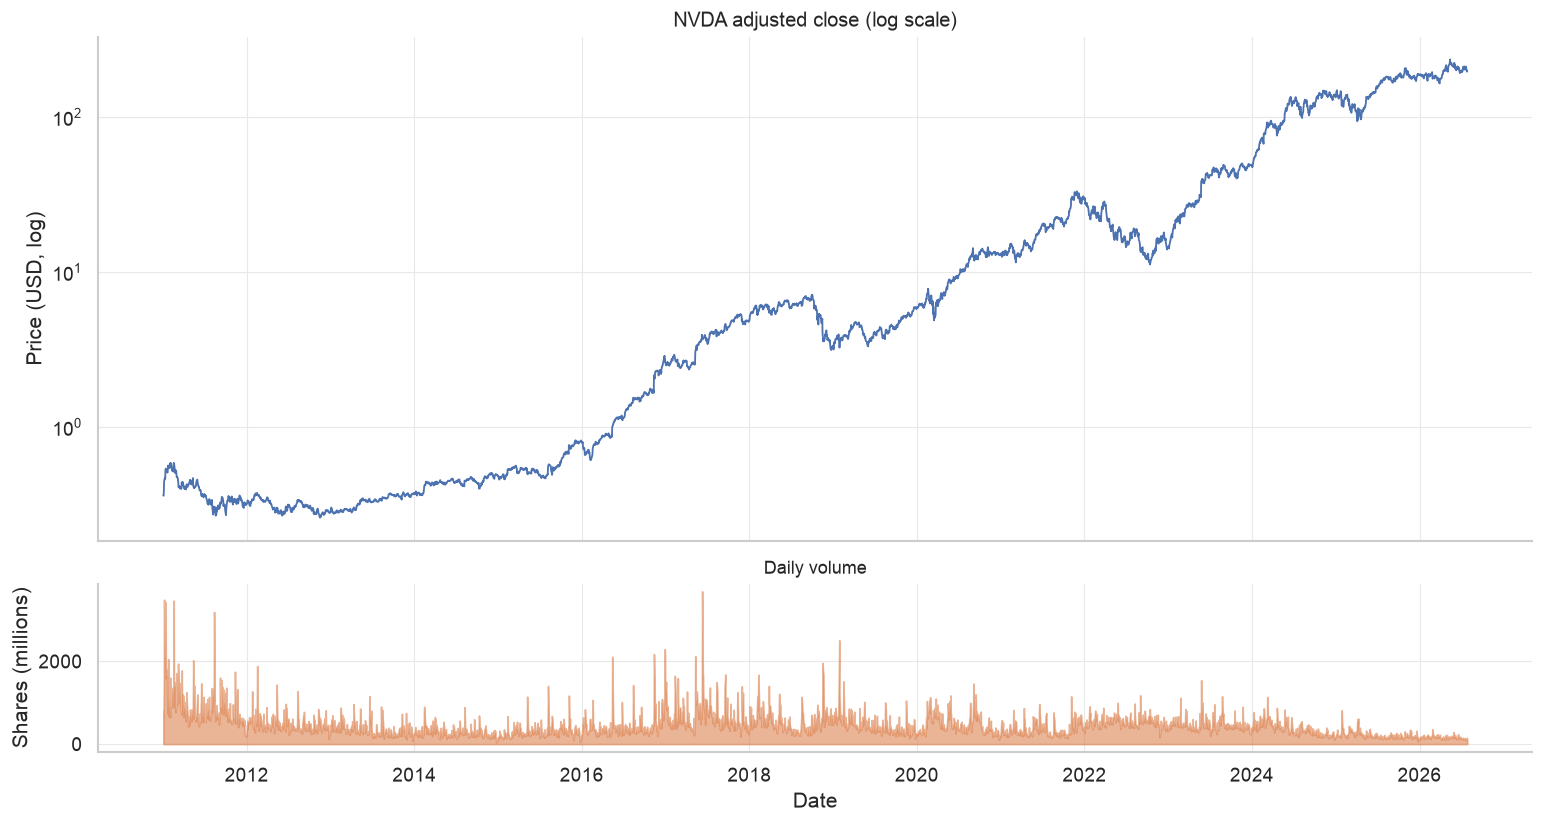

In [7]:
fig = plot_price_and_volume(featured)
plt.show()
save_figure(fig, "price_and_volume", FIG_DIR / "eda")

The log axis is necessary. NVDA compounded more than a hundredfold here, and on a linear scale the whole first decade flattens into a line at the bottom.

Volume steps up permanently around 2016 and again in 2023. That is why the volume feature is standardized against a rolling one-year baseline instead of used raw: a fixed threshold would call every recent day high volume simply because the company grew.

### 5.2 Return distribution

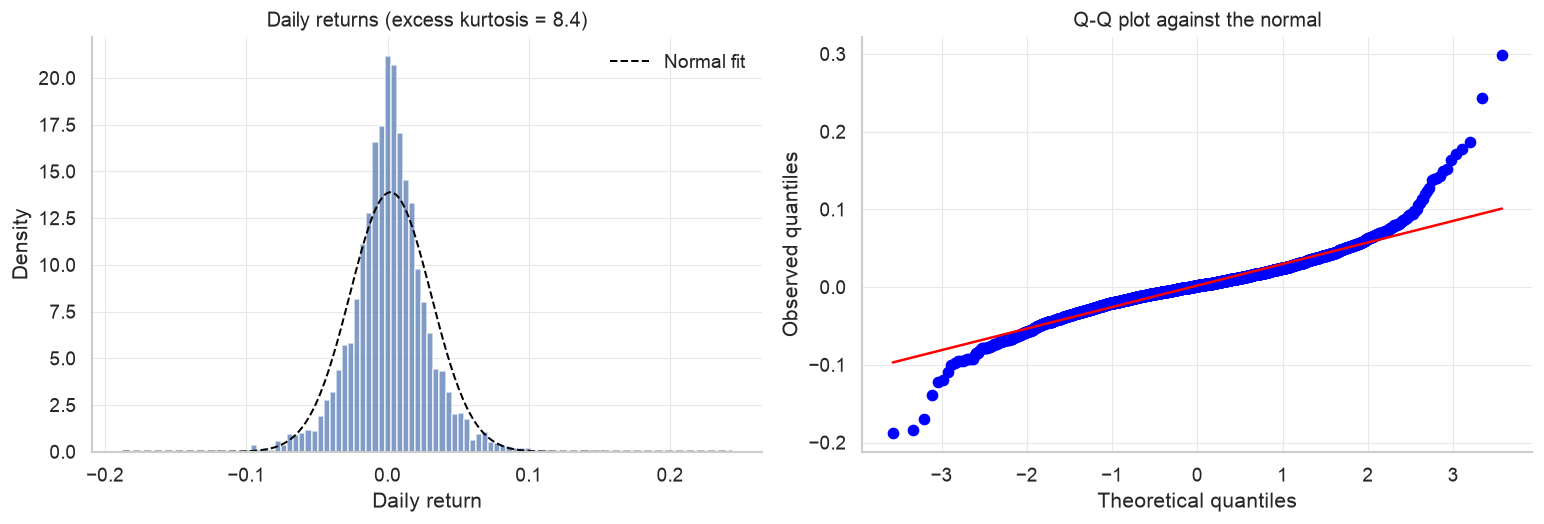

In [8]:
fig = plot_return_distribution(featured)
plt.show()
save_figure(fig, "return_distribution", FIG_DIR / "eda")

The usual shape. A sharp peak near zero, tails much heavier than a normal allows, and a Q-Q plot that bends away at both ends.

Two things follow. Any method assuming Gaussian returns is mis-specified here. And the extreme days are frequent enough to matter rather than being curiosities. It is also why the regime features include volatility directly: in a fat-tailed series, how much the market moves is more stable and more learnable than which way it went.

### 5.3 Volatility and drawdown

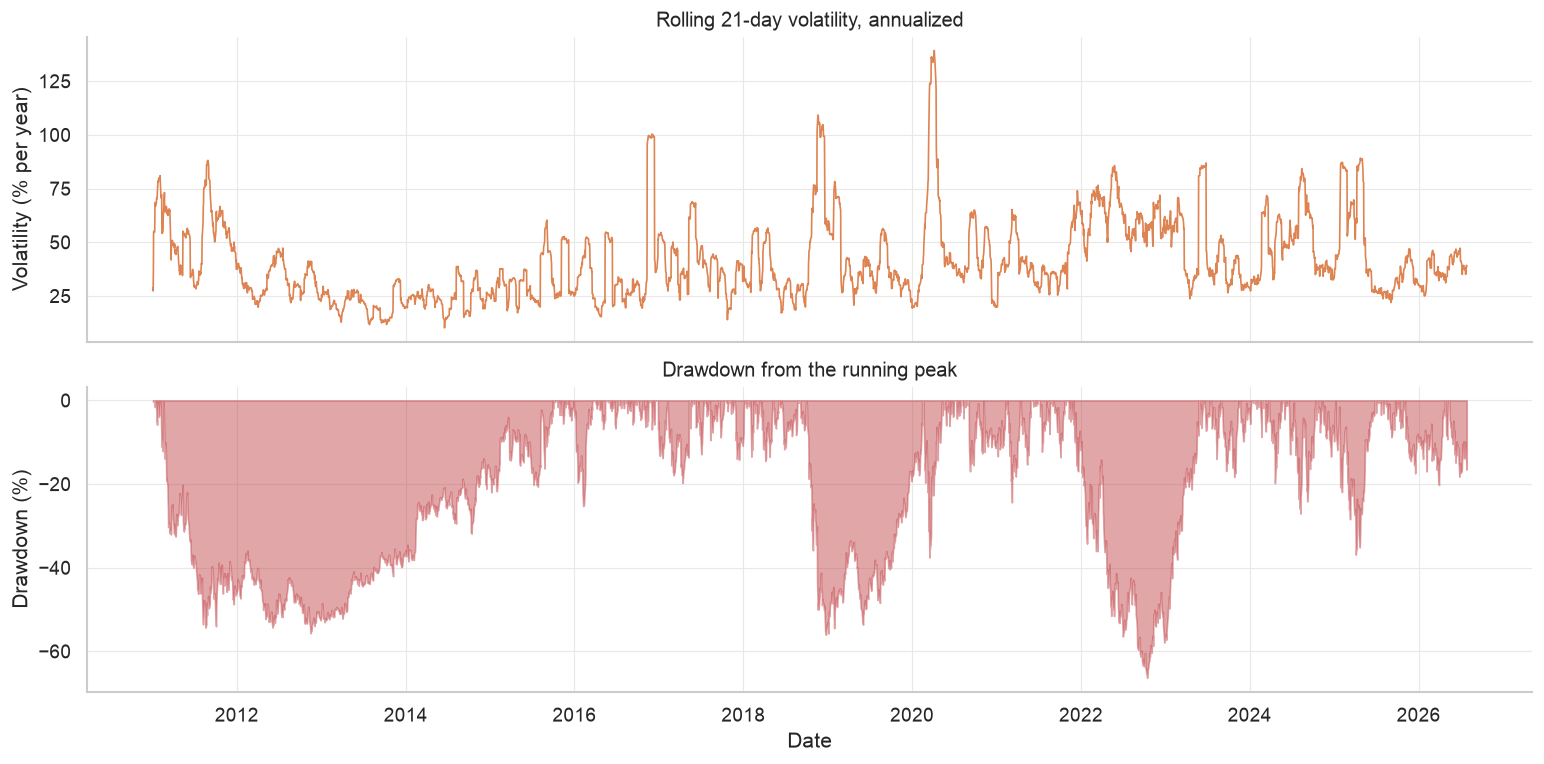

In [9]:
fig = plot_volatility_and_drawdown(featured)
plt.show()
save_figure(fig, "volatility_and_drawdown", FIG_DIR / "eda")

Volatility is not constant. It clusters: quiet stretches follow quiet ones, violent stretches follow violent ones.

That persistence is the most important fact behind this whole project, because it is what makes a regime label useful. If volatility were independent day to day, yesterday's regime would tell you nothing about today and conditioning a policy on it would be noise.

The drawdown panel is the counterweight to the price chart. Even this stock spent long stretches far below its high, including a fall of about two thirds in 2022. An agent that stays long inherits all of that, which is what the risk metrics in Section 10 are for.

---
## 6. Unsupervised learning: finding market regimes

The brief allows clustering or dimensionality reduction. I use both, for different jobs.

Clustering gives the discrete regime label that goes into the agent's state. A tabular policy needs a finite state, and a trader needs something they can argue with. Dimensionality reduction is there to check that the cluster structure is real rather than K-means being forced onto a cloud with no groups in it.

### 6.1 How many regimes?

The number of regimes changes what the labels mean, so I pick it from diagnostics on the training window instead of assuming it.

In [10]:
x_train, x_test = regime_matrix(train), regime_matrix(test)
selection = rg.select_n_regimes(x_train)
selection

,inertia,silhouette,davies_bouldin,calinski_harabasz
k,,,,
2,9834.8,0.2955,1.5550,703.3
3,8056.3,0.3220,1.3347,706.6
4,7209.9,0.3001,1.4129,624.5
5,6601.1,0.2557,1.3909,569.3
6,6039.4,0.2840,1.3042,544.3
7,5550.9,0.2016,1.3140,530.1
8,5177.4,0.2043,1.3247,512.8


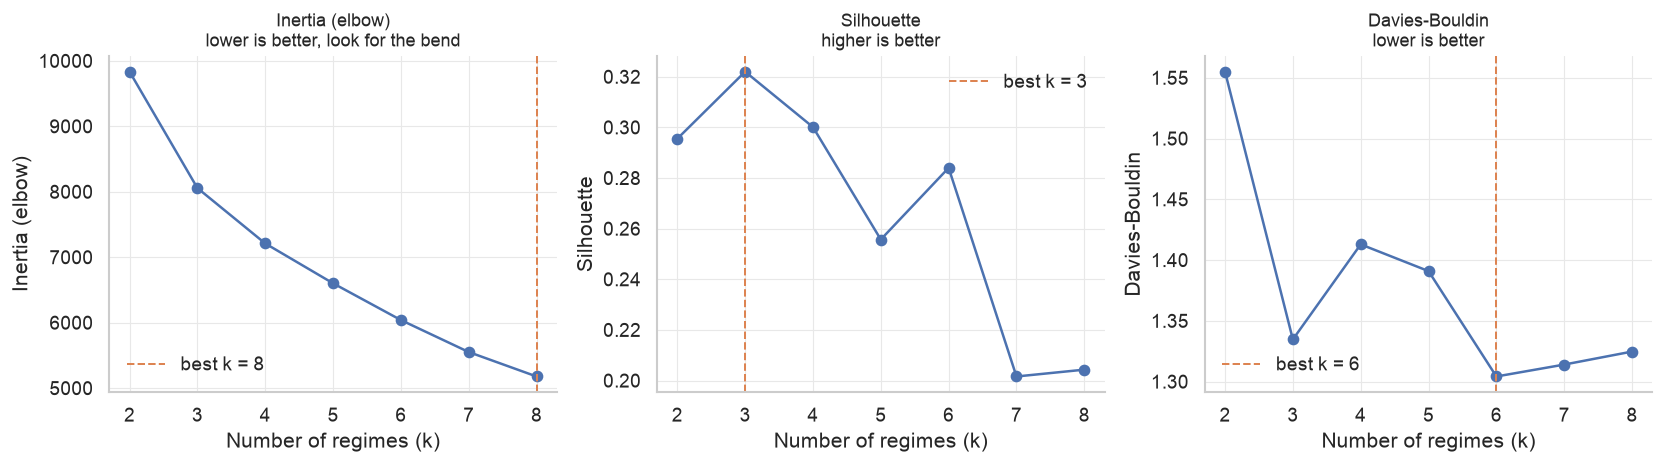

In [11]:
fig = plot_regime_selection(selection)
plt.show()
save_figure(fig, "regime_selection", FIG_DIR / "regimes")

Inertia falls the whole way, as it always does, and only bends softly, so on its own it picks nothing. The other two disagree, and that is worth saying rather than smoothing over. Silhouette peaks at **k = 3** (0.322) and Calinski-Harabasz peaks there too (706.6). Davies-Bouldin's lowest value is at **k = 6** (1.3042), with k = 3 second at 1.3347.

So two of three criteria say three regimes and the third prefers six by 0.03, which is slight. I take three, for two more reasons. Six states split a decade of daily data so thin that a tabular agent barely visits each one. And six market states stop being describable in a sentence, which defeats the point of building regimes you can read. It is a judgment call, not a unanimous verdict, and Section 9 tests it where it counts: whether the labels actually improve the agent.

### 6.2 K-means regimes, fitted on the training window only

In [12]:
kmeans_model = rg.fit_kmeans_regimes(x_train, train["return"].to_numpy(), N_REGIMES)

# The frozen model is the only path by which any day, train or test, gets a label.
train["regime"] = rg.assign_regimes(kmeans_model, x_train)
test["regime"] = rg.assign_regimes(kmeans_model, x_test)

print("Cluster quality on the training window:", rg.cluster_quality(x_train, train["regime"].to_numpy()))

Cluster quality on the training window: {'silhouette': 0.322, 'davies_bouldin': 1.3347, 'n_clusters': 3}


In [13]:
rg.regime_profile(train, "regime")

,days,mean_return_bps,ann_return_pct,ann_vol_pct,hit_ratio,mean_momentum,mean_dist_high,share_%
regime,,,,,,,,
0,281,200.9,506.3,69.2,0.701,0.1992,-0.0622,11.2
1,1571,16.8,42.3,26.2,0.539,0.0446,-0.0606,62.4
2,665,-56.9,-143.3,51.5,0.420,-0.0461,-0.3635,26.4


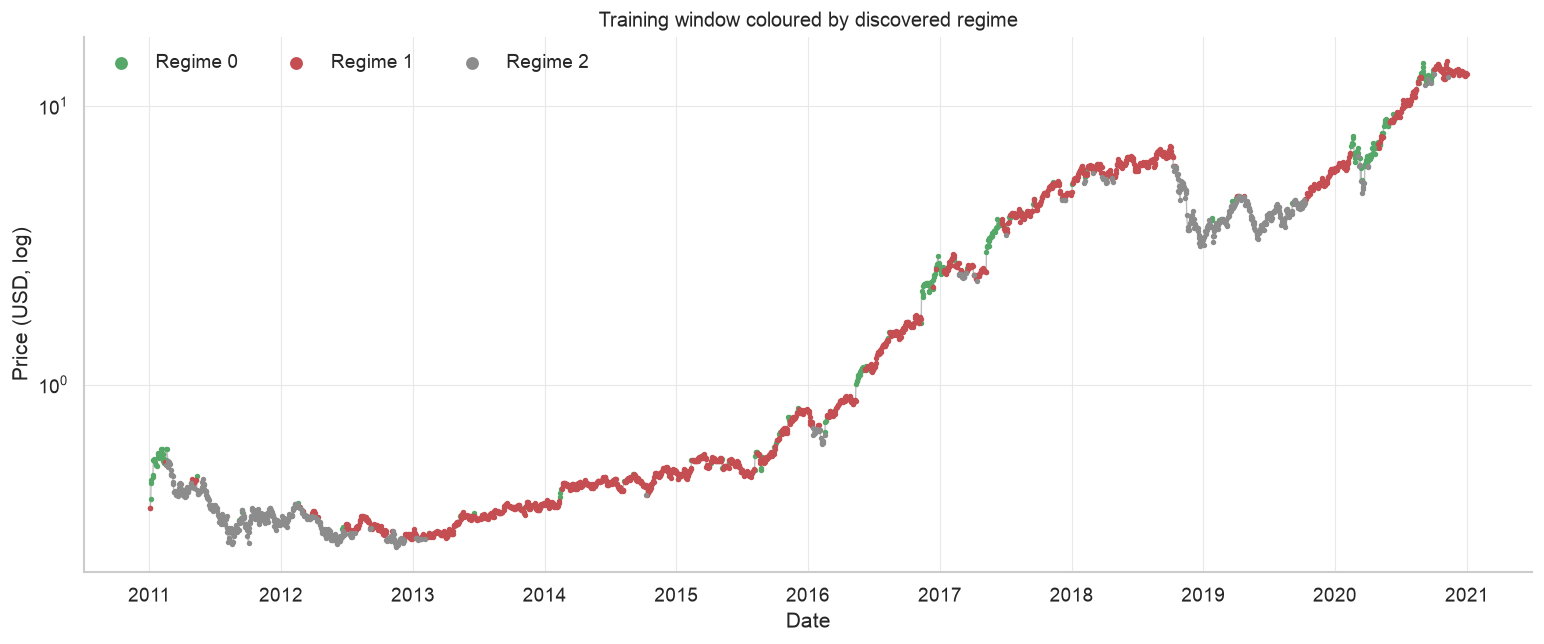

In [14]:
fig = plot_regime_timeline(train, "regime", "Training window coloured by discovered regime")
plt.show()
save_figure(fig, "regime_timeline_train", FIG_DIR / "regimes")

Coloring the price by regime is what makes the model checkable instead of merely plausible. The drawdown regime lines up with the 2011 and 2018 declines and the COVID crash. The melt-up marks the steep 2016 and 2020 advances. The calm advance fills the long grinding stretches between them.

A trader would have named those same periods without a model, which is what gives the labels credibility before they get used for anything.

Labels are reordered so regime 0 always has the highest mean return. K-means numbers clusters arbitrarily, so without that step the same regime changes identity between runs and everything written about "regime 1" quietly rots.

The profile makes the three states nameable, which is the point of doing this unsupervised instead of hand-writing thresholds:

- **Regime 0, the melt-up.** 11% of training days. Over 500% annualized at 69% volatility, momentum strongly positive, price near its high, hit ratio 0.70. Violent upside, not calm.
- **Regime 1, the calm advance.** The workhorse at 62% of days. 42% annualized at 26% volatility, the lowest of the three, sitting near the high. The ordinary bull grind.
- **Regime 2, the drawdown.** 26% of days. Negative drift, 51% volatility, price averaging 36% below the yearly high, hit ratio 0.42. Falling and frightened.

Volatility and distance from the high separate these states far better than the sign of returns does. The EDA said the same thing, and it is why those two features carry most of the weight.

### 6.3 Do the regimes survive out of sample?

A regime definition that only describes the training decade is useless. Applying the frozen model to the sealed test window is the real test.

In [15]:
rg.regime_profile(test, "regime")

,days,mean_return_bps,ann_return_pct,ann_vol_pct,hit_ratio,mean_momentum,mean_dist_high,share_%
regime,,,,,,,,
0,210,260.1,655.5,66.6,0.719,0.2381,-0.0882,15.0
1,776,19.6,49.3,33.6,0.545,0.0626,-0.0604,55.5
2,411,-86.2,-217.2,58.5,0.421,-0.0616,-0.3433,29.4


This is the strongest evidence in the unsupervised half of the project. Centroids fitted on 2010 to 2020 and never updated give the same ordering on 2021 to 2026: regime 0 still the violent advance, regime 1 still the calm grind, regime 2 still the volatile drawdown with the worst hit ratio and a price far below the high.

The magnitudes move, which they should, since the test period holds both a savage bear market and an exceptional rally. But the identity of each state holds. So these are not curve-fitted labels. They describe conditions durable enough to put in an agent's state.

### 6.4 Regime persistence

A label only helps a policy if it persists. If regimes flickered day to day, yesterday's state would say nothing about today.

In [16]:
transitions = rg.transition_matrix(train["regime"].to_numpy())
transitions

to_regime,0,1,2
from_regime,,,
0,0.694,0.228,0.078
1,0.039,0.929,0.031
2,0.036,0.071,0.893


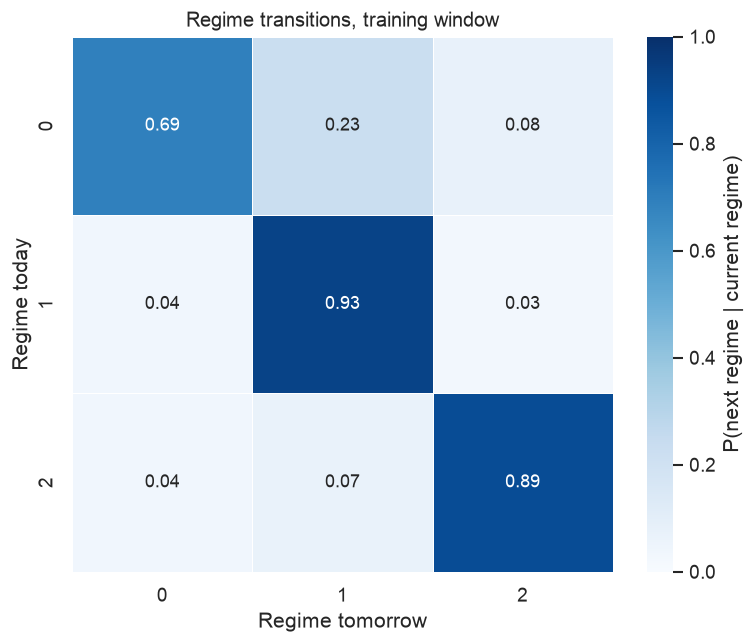

In [17]:
fig = plot_transition_matrix(transitions, "Regime transitions, training window")
plt.show()
save_figure(fig, "transition_matrix", FIG_DIR / "regimes")

The diagonal is the whole argument. The calm advance repeats 93% of the time, the drawdown 89%, and even the melt-up, the rarest and most explosive state, persists 69%. Regimes come in runs lasting weeks, not isolated days.

That is what makes conditioning a policy on the label defensible. It also shows the states are not just a relabeling of "yesterday was up or down", since a sign-of-return label would sit near a coin flip on the diagonal. The off-diagonal makes sense too: the melt-up decays into the calm advance far more often than it collapses straight into a drawdown.

### 6.5 Alternative clusterings as a shape check

K-means assumes roughly round, similar-sized clusters. If the structure were really density-based, that assumption would be quietly wrong, so two alternatives run on the same training features.

In [18]:
dbscan_labels, dbscan_info = rg.fit_dbscan(x_train)
agglo_labels = rg.fit_agglomerative(x_train)

print("DBSCAN:", dbscan_info)
print("DBSCAN quality      :", rg.cluster_quality(x_train, dbscan_labels))
print("Agglomerative (Ward):", rg.cluster_quality(x_train, agglo_labels))
print("K-means             :", rg.cluster_quality(x_train, train["regime"].to_numpy()))

DBSCAN: {'n_clusters': 1, 'n_noise': 438, 'noise_share_%': np.float64(17.4)}
DBSCAN quality      : {'silhouette': nan, 'davies_bouldin': nan, 'n_clusters': 0}
Agglomerative (Ward): {'silhouette': 0.2383, 'davies_bouldin': 1.6179, 'n_clusters': 3}
K-means             : {'silhouette': 0.322, 'davies_bouldin': 1.3347, 'n_clusters': 3}


Ward-linkage clustering also lands on a three-way split, though a looser one: silhouette 0.238 against K-means' 0.322. Two algorithms with different objectives finding the same number of groups suggests the partition belongs to the data rather than to K-means. The weaker score says the boundaries are genuinely fuzzy.

DBSCAN behaves differently, and the disagreement is informative rather than a failure. Market-state space has no clean density gaps. It is a continuum that thins toward the extremes, so DBSCAN either merges everything into one blob or strands a large share of days as noise depending on `eps`. Here it did both: one cluster and 17% noise. That is a real finding about the geometry, and it is also why DBSCAN never produces the agent's state, since it cannot label a day it has not seen.

### 6.6 Seeing the structure: PCA and UMAP

Two projections, two jobs. PCA is linear and its components read as weighted mixes of the original features, so it says what separates the regimes. UMAP keeps local neighborhoods and is better at showing whether the groups are actually distinct.

### 6.5b K-means against a hidden Markov model

K-means has one obvious flaw for this job: it treats every day as independent. That is plainly wrong for markets, where a volatile day is very likely followed by another one. A Gaussian HMM models that persistence directly through a transition matrix, so it is the model the problem actually asks for.

Both are fitted on the training window and compared on the property that matters for the agent: how long the regimes last.

In [19]:
hmm_model = rg.fit_hmm_regimes(x_train, train["return"].to_numpy(), N_REGIMES)
train["regime_hmm"] = rg.assign_hmm_regimes(hmm_model, x_train)

print(f"HMM converged: {hmm_model['converged']}")
print("K-means quality:", rg.cluster_quality(x_train, train["regime"].to_numpy()))
print("HMM quality    :", rg.cluster_quality(x_train, train["regime_hmm"].to_numpy()))

km_diag = np.diag(rg.transition_matrix(train["regime"].to_numpy()).to_numpy()).mean()
hmm_diag = np.diag(rg.transition_matrix(train["regime_hmm"].to_numpy()).to_numpy()).mean()
print(f"\nMean persistence (diagonal): K-means {km_diag:.3f}   HMM {hmm_diag:.3f}")

HMM converged: True
K-means quality: {'silhouette': 0.322, 'davies_bouldin': 1.3347, 'n_clusters': 3}
HMM quality    : {'silhouette': 0.1696, 'davies_bouldin': 2.3197, 'n_clusters': 3}

Mean persistence (diagonal): K-means 0.839   HMM 0.969


In [20]:
rg.regime_profile(train, "regime_hmm")

,days,mean_return_bps,ann_return_pct,ann_vol_pct,hit_ratio,mean_momentum,mean_dist_high,share_%
regime_hmm,,,,,,,,
0,677,38.5,97.0,53.3,0.545,0.0746,-0.0801,26.9
1,1047,21.2,53.5,24.4,0.545,0.0622,-0.0248,41.6
2,793,-4.2,-10.5,49.7,0.482,-0.0256,-0.3458,31.5


The HMM does what it promises. Mean persistence rises from 0.839 to 0.969, so its regimes last far longer, and it still recovers the same shape: a positive-drift state, a calm middle state, and a drawdown state sitting 35% below the yearly high.

It pays for that with compactness. Silhouette drops from 0.322 to 0.170 and Davies-Bouldin rises from 1.33 to 2.32, because the HMM will keep a day in the current state on the strength of its neighbours even when the day's own features sit closer to another cluster. That is the transition prior doing its job, and it is why the internal metrics, which only look at feature-space geometry, mark it down. The separation between its regimes is also milder: +97%, +54%, and -10% annualized, against K-means' +506%, +42%, and -143%.

I keep the K-means label as the agent's state feature, for one practical reason. `predict` on a frozen K-means pipeline is a per-day lookup, while an HMM decodes a whole sequence, so a test-day label would depend on the days around it. Keeping the state assignment strictly per-day makes the no-look-ahead guarantee easy to state and easy to test. The HMM is arguably the better description of the market; K-means is the safer thing to hand an agent.

In [21]:
pca_pipe = rg.fit_pca(x_train)
rg.pca_loadings(pca_pipe, list(x_train.columns))

,PC1,PC2
return,0.347,0.278
volatility_21,-0.267,0.666
momentum_21,0.606,0.214
dist_252d_high,0.659,-0.152
volume_zscore,0.082,0.640
explained_variance_%,32.200,28.500


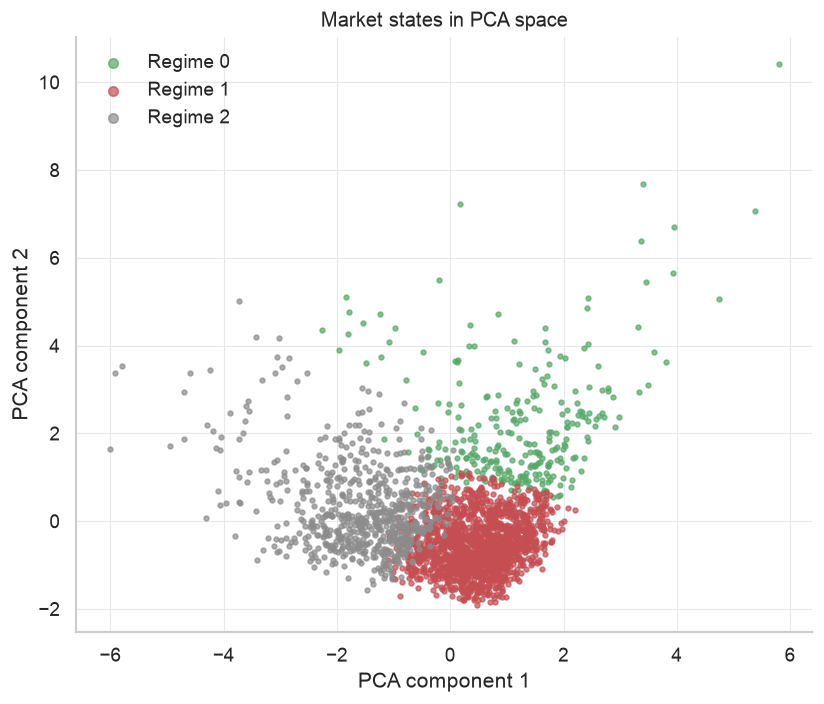

In [22]:
pca_train = pca_pipe.transform(x_train)
fig = plot_regime_projection(pca_train, train["regime"].to_numpy(), "PCA")
plt.show()
save_figure(fig, "regimes_pca", FIG_DIR / "regimes")

/Users/hussein-loubani/Turing College/Module 3/Sprint 4/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


/Users/hussein-loubani/Turing College/Module 3/Sprint 4/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


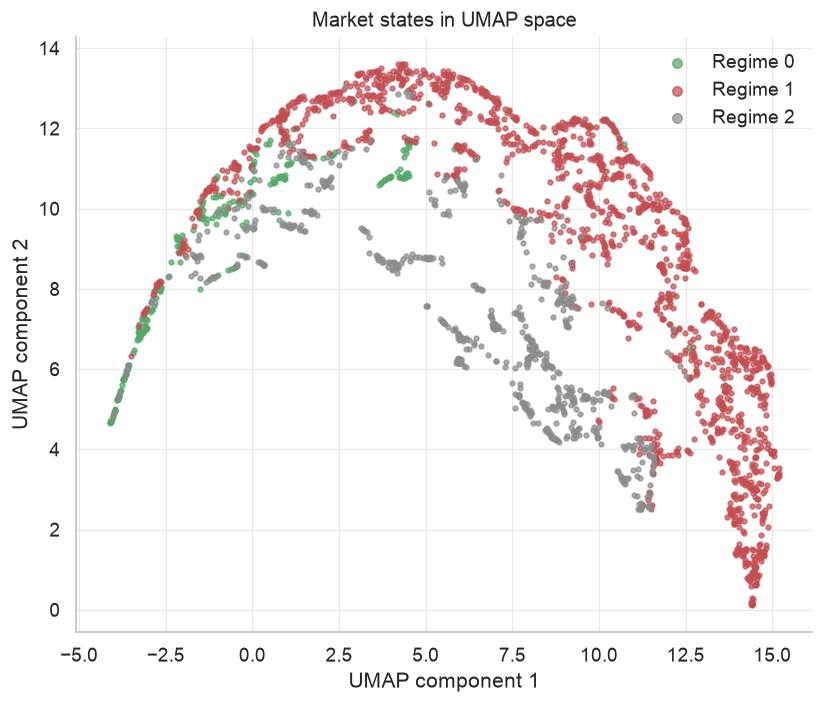

In [23]:
import umap

reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, n_components=2,
                    random_state=RANDOM_SEED)
umap_train = reducer.fit_transform(x_train)   # fitted on training days only

fig = plot_regime_projection(umap_train, train["regime"].to_numpy(), "UMAP")
plt.show()
save_figure(fig, "regimes_umap", FIG_DIR / "regimes")

The PCA loadings name the axes. The first component is volatility and distance from the high moving together, which is the market-stress axis. The second separates momentum and recent return, the direction axis. That ordering is itself a result: the biggest source of variation across market days is how stressed the market is, not which way it went.

UMAP shows the regimes sitting in coherent neighborhoods with real overlap at the edges. The overlap is expected and honest, because regimes are not crisp categories and boundary days really are ambiguous. What matters is that the centers are distinct, which is all a policy needs to behave differently in one state than another.

### 6.7 Anomaly detection

Anomalies matter here for one reason. An agent meeting a market state unlike anything in training is extrapolating, and knowing how often that happens on test bounds how much to trust the backtest.

In [24]:
x_all = regime_matrix(featured)
anomalies = rg.detect_anomalies(x_train, x_all)

featured["anomaly_iso"] = anomalies["isolation_forest"]
test_anomaly_rate = (featured.loc[featured["date"] >= pd.Timestamp(SPLIT_DATE), "anomaly_iso"] == -1).mean()
train_anomaly_rate = (featured.loc[featured["date"] < pd.Timestamp(SPLIT_DATE), "anomaly_iso"] == -1).mean()
print(f"Days flagged anomalous by Isolation Forest, train: {train_anomaly_rate:.1%}")
print(f"Days flagged anomalous by Isolation Forest, test : {test_anomaly_rate:.1%}")

Days flagged anomalous by Isolation Forest, train: 2.0%
Days flagged anomalous by Isolation Forest, test : 1.8%


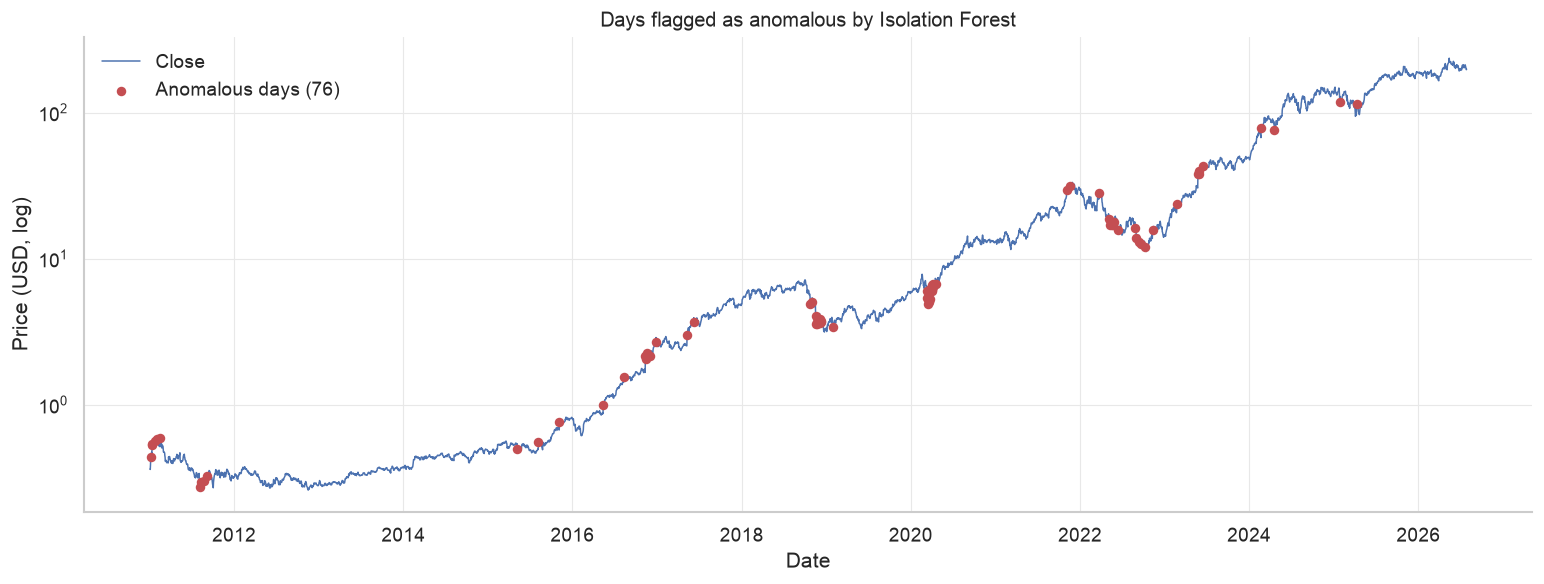

In [25]:
fig = plot_anomalies(featured, featured["anomaly_iso"].to_numpy())
plt.show()
save_figure(fig, "anomalies", FIG_DIR / "regimes")

The flagged days sit around the March 2020 crash, the 2022 drawdown, and the sharpest earnings reactions, which is what a working detector should do.

The comparison that matters is between the two rates. The detector was fitted on training days with a 2% contamination target, so the 2.0% training rate is true by construction and the test rate is the real measurement. It comes back at 1.8%, slightly below training. That is the reassuring answer: the 2021 to 2026 market states are not stranger than what the agent learned from, so the backtest is evaluation and not extrapolation. At 10% I would have had to discount everything in Section 10.

### 6.8 Unsupervised findings

- Three regimes is a reasoned choice, not an assumption. Silhouette and Calinski-Harabasz both pick k = 3; Davies-Bouldin narrowly prefers 6; three wins on learnability and interpretability.
- The regimes are readable in trading language: a violent melt-up, a calm advance holding 62% of days, and a drawdown averaging 36% below the yearly high.
- They generalize. Frozen 2010 to 2020 centroids reproduce the same ordering on 2021 to 2026.
- They persist, with diagonal transitions of 0.69, 0.93, and 0.89.
- Ward clustering finds similar structure. DBSCAN does not, because market-state space is a continuum rather than a set of islands.
- Volatility and distance from the high separate regimes far better than the sign of returns. That keeps coming up in this data.

---
## 7. The reinforcement learning environment

### 7.1 The reward, exactly as specified

$$r_t = a_{t-1} \cdot \text{return}_t - \text{cost} \cdot |a_t - a_{t-1}|$$

Two properties drive everything the agent learns. Yesterday's position earns today's return, so an action taken now cannot collect a return already observed. And the cost is proportional to how far the position moves, so a short-to-long flip costs twice a flat-to-long entry.

Every number in this notebook inherits that formula, so it is pinned by unit tests with hand-computed values rather than trusted. The suite also asserts the leakage guards: bin edges and cluster centroids must depend on training data alone.

In [26]:
import subprocess

result = subprocess.run(["uv", "run", "pytest", "tests/", "-q", "--no-header"],
                        cwd=Path.cwd().parent, capture_output=True, text=True)
print(result.stdout.strip().splitlines()[-1])

19 passed in 0.78s


### 7.2 Discretizing the state

Tabular Q-learning needs a finite state space, so the three continuous features are cut into terciles. The edges are quantiles of the training window only. Computing them over the full history would let the test period decide what counts as high volatility, which is the same leak as fitting the clusters on everything.

In [27]:
BIN_COLUMNS = ["volatility_21", "momentum_21", "dist_252d_high"]
bin_edges = fit_binner(train, BIN_COLUMNS, n_bins=3)
train = apply_binner(train, bin_edges)
test = apply_binner(test, bin_edges)

MARKET_STATE = [f"{c}_bin" for c in BIN_COLUMNS]
REGIME_STATE = MARKET_STATE + ["regime"]

print("Market-only state columns :", MARKET_STATE)
print("Regime-augmented state    :", REGIME_STATE)
print(f"\nReachable states: market only = {3**3} x 3 positions = {3**3 * 3}")
print(f"                 with regime  = {3**3 * N_REGIMES} x 3 positions = {3**3 * N_REGIMES * 3}")

Market-only state columns : ['volatility_21_bin', 'momentum_21_bin', 'dist_252d_high_bin']
Regime-augmented state    : ['volatility_21_bin', 'momentum_21_bin', 'dist_252d_high_bin', 'regime']

Reachable states: market only = 27 x 3 positions = 81
                 with regime  = 81 x 3 positions = 243


Adding the regime triples the state space. That is the cost side of the ablation in Section 9, and it is real: with a fixed number of training days, more states means fewer visits each and a noisier table. The question is whether the label carries enough information to be worth that.

### 7.3 A first look at the environment

In [28]:
demo_env = TradingEnv(train, MARKET_STATE)
print(f"Tradeable steps in the training episode: {demo_env.n_steps:,}")
print(f"Transaction cost: {TRANSACTION_COST:.3%} of notional per unit of position change")
print(f"Action space: {ACTIONS}")
print(f"Example state (features..., position): {demo_env.reset()}")

Tradeable steps in the training episode: 2,516
Transaction cost: 0.100% of notional per unit of position change
Action space: (-1, 0, 1)
Example state (features..., position): (1, 2, 0, 0)


---
## 8. Tabular agents: Q-learning and SARSA

Both agents are tabular, and that is a choice rather than a limitation. The state space is small and discrete, so a table is enough, and it has one big advantage for a review: I can read the learned policy. A neural policy that happens to beat buy-and-hold over one bull run proves nothing. A table showing what the agent does in each regime is a claim you can check.

**Q-learning is off-policy.** Its update bootstraps from the best next action, so it learns the value of the greedy policy while still exploring. **SARSA is on-policy.** It bootstraps from the action actually taken next, so it learns the value of the policy it is really following, mistakes included. That difference is not academic here: SARSA prices in the cost of its own exploration and settles on tamer positions.

### 8.1 A note on the learning rate

My first run used the textbook `alpha = 0.1` and gave a degenerate result worth writing down: the agent never traded at all.

Daily rewards here are about 0.2% with a 3% standard deviation, so nearly every update target is noise. At a high learning rate the table chases that noise instead of averaging it. The learned values sat around 0.001 with no stable ordering, and the greedy action from every flat state was to stay flat, which is absorbing. Dropping the rate to 0.005 lets the table average many noisy targets, which is what a value estimate is supposed to be. I picked it on that reasoning and checked it against training behavior. The test window was never consulted.

In [29]:
env_market = TradingEnv(train, MARKET_STATE)
env_regime = TradingEnv(train, REGIME_STATE)

agents = {}
curves = {}
for label, env in [("market only", env_market), ("market + regime", env_regime)]:
    for AgentClass, name in ((QLearningAgent, "Q-learning"), (SarsaAgent, "SARSA")):
        agent = AgentClass()
        curves[f"{name} [{label}]"] = agent.train(env, n_episodes=600)
        agents[f"{name} [{label}]"] = agent
        print(f"{name} [{label}]: {len(agent.q)} states visited")

Q-learning [market only]: 81 states visited


SARSA [market only]: 81 states visited


Q-learning [market + regime]: 174 states visited


SARSA [market + regime]: 174 states visited


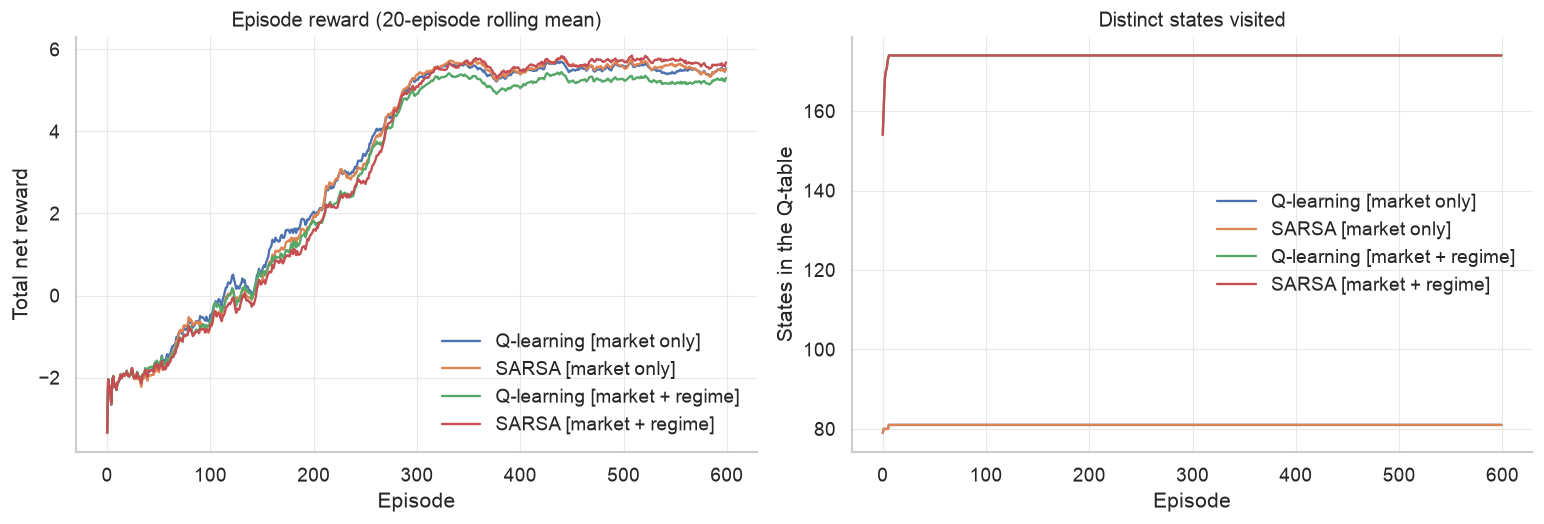

In [30]:
fig = plot_learning_curves(curves)
plt.show()
save_figure(fig, "learning_curves", FIG_DIR / "rl")

Both algorithms improve as epsilon decays and then flatten, which is what convergence looks like on a fixed tape. The right panel shows state coverage saturating early, so the tables are not still filling in when training stops.

The regime-augmented agents visit about twice as many states, which is the dilution cost made visible. The reward curves stay noisy throughout because the tape is noisy and epsilon never reaches zero, so read the rolling mean rather than any single episode.

### 8.2 What did the agent actually learn?

In [31]:
best_agent = agents["SARSA [market + regime]"]
policy_table = best_agent.policy_table()
print(f"States in the table: {len(policy_table)}")
policy_table.head(10)

States in the table: 174


,state,Q(a=-1),Q(a=0),Q(a=1),greedy_action,visits_value_sum
0,"(0, 0, 0, 1, -1)",-0.004180,-0.004536,0.027761,1,0.036476
1,"(0, 0, 0, 1, 0)",0.000804,0.004500,0.045954,1,0.051258
2,"(0, 0, 0, 1, 1)",0.011719,0.015083,0.049773,1,0.076576
3,"(0, 0, 0, 2, -1)",0.053339,0.016465,0.014515,-1,0.084319
4,"(0, 0, 0, 2, 0)",0.049073,0.002701,0.001921,-1,0.053694
5,"(0, 0, 0, 2, 1)",0.004791,0.046951,0.007236,0,0.058979
6,"(0, 0, 1, 1, -1)",0.007368,0.006726,0.062621,1,0.076715
7,"(0, 0, 1, 1, 0)",0.003354,0.004499,0.051746,1,0.059598
8,"(0, 0, 1, 1, 1)",0.051345,0.042567,0.066559,1,0.160471
9,"(0, 0, 2, 1, -1)",0.064103,0.010510,0.010605,-1,0.085218


---
## 9. Does the unsupervised layer help? An ablation

This is the question the brief actually asks, and it only gets a defensible answer if the two setups differ in exactly one thing. They do. Same algorithms, same hyperparameters, same seeds, same training data, same evaluation window. The only difference is whether the regime label is in the state.

Everything is evaluated on the sealed test window, once.

In [32]:
ledgers = {
    "Buy and hold": TradingEnv(test, MARKET_STATE).run_policy(buy_and_hold_policy),
    "Flat": TradingEnv(test, MARKET_STATE).run_policy(flat_policy),
    "Random": TradingEnv(test, MARKET_STATE).run_policy(random_policy_factory()),
}
for label, cols in [("market only", MARKET_STATE), ("market + regime", REGIME_STATE)]:
    for name in ("Q-learning", "SARSA"):
        key = f"{name} [{label}]"
        ledgers[key] = TradingEnv(test, cols).run_policy(agents[key].greedy_policy())

summary = compare_policies(ledgers)
summary

,cumulative_pnl_%,total_growth_x,ann_return_%,ann_vol_%,sharpe,max_drawdown_%,hit_ratio,days_in_market_%,turnover_per_year,cost_drag_%,days
policy,,,,,,,,,,,
Buy and hold,1381.34,14.813,62.68,50.97,1.23,-66.34,0.534,99.9,0.2,0.1,1396
SARSA [market + regime],1360.19,14.602,62.25,49.94,1.25,-67.20,0.540,96.0,16.1,8.9,1396
Q-learning [market + regime],749.32,8.493,47.13,50.50,0.93,-66.74,0.537,97.4,26.2,14.5,1396
SARSA [market only],705.92,8.059,45.75,50.98,0.90,-59.95,0.537,99.4,13.2,7.3,1396
Q-learning [market only],407.73,5.077,34.08,51.04,0.67,-61.30,0.534,99.9,19.0,10.5,1396
Flat,0.00,1.000,0.00,0.00,NaN,0.00,NaN,0.0,0.0,0.0,1396
Random,-96.02,0.040,-44.11,42.08,-1.05,-96.51,0.479,66.5,221.3,122.6,1396


**The ablation favors the unsupervised layer.** Same algorithm, nothing added but the regime label:

| Agent | Market only | Market + regime | Change |
|---|---|---|---|
| SARSA | +706% | +1360% | roughly double |
| Q-learning | +408% | +749% | roughly double |

Both nearly double their cumulative PnL and both improve on Sharpe, so this is not one lucky configuration. The label carries information the three binned features do not, even though it was built from those same features. That deserves an explanation rather than applause.

Clustering does a non-linear, joint compression that independent tercile bins cannot. Separate bins treat the features as unrelated: they can say "volatility is high" and "momentum is low" as two facts. The regime label says "this particular combination is the drawdown state", which is a statement about the whole configuration. For a tabular agent that is decisive, because it gets one coherent state instead of a conjunction it has to learn to assemble.

The turnover column shows a second cost I did not expect: the regime agents trade **more**, not less. SARSA goes from 13.2 to 16.1 units of turnover a year and Q-learning from 19.0 to 26.2, pushing cost drag from 7.3% to 8.9% and from 10.5% to 14.5%. The label makes them more willing to change position, presumably because it separates situations the market-only state lumped together.

They still come out far ahead, and that is the finding: the extra gross return the regime buys is several times bigger than the extra costs and state dilution it creates. An improvement that survives paying for itself is more convincing than a free one.

### 9.1 How the regime changes behavior

In [33]:
action_distribution(ledgers)

,action_-1_%,action_0_%,action_1_%
Buy and hold,0.0,0.0,100.0
Flat,0.0,100.0,0.0
Random,32.1,33.5,34.5
Q-learning [market only],9.2,0.1,90.7
SARSA [market only],8.0,0.6,91.5
Q-learning [market + regime],4.1,2.5,93.4
SARSA [market + regime],1.2,3.9,94.8


In [34]:
regime_map = regime_action_map(ledgers["SARSA [market + regime]"], test["regime"])
regime_map

action,short_%,flat_%,long_%,days,mean_net_return_bps
regime,,,,,
0,0.5,20.0,79.5,210,25.74
1,2.1,1.5,96.4,775,16.29
2,0.0,0.2,99.8,411,38.06


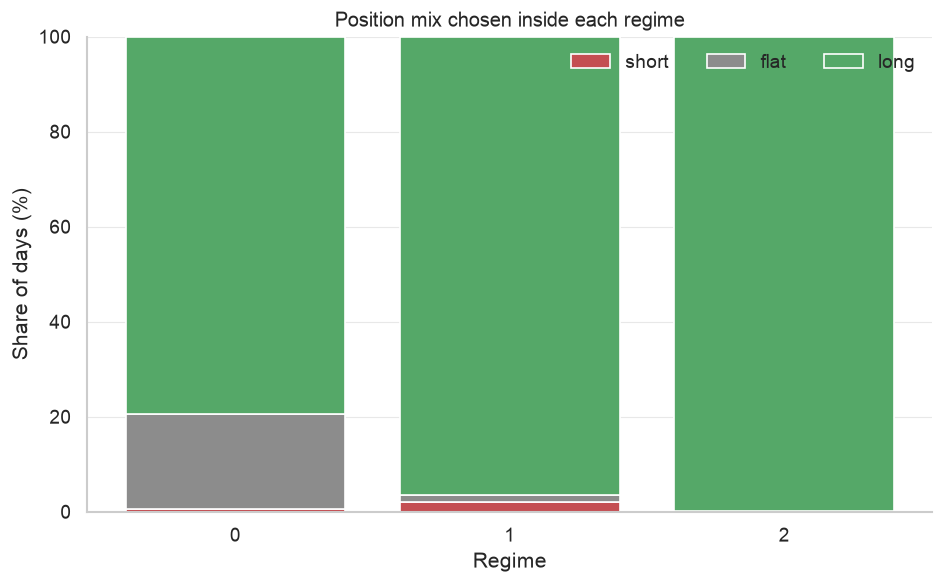

In [35]:
fig = plot_policy_by_regime(regime_map)
plt.show()
save_figure(fig, "policy_by_regime", FIG_DIR / "rl")

The action mix shows the agents are reacting to the state rather than picking one position and holding it. They sit long most of the time, which is right for this asset over this period, but the mix shifts by regime and the market-only agents choose measurably different mixes from the regime ones.

One result looks wrong at first and is worth spelling out. The agent stays long through the drawdown regime, and that regime shows the **highest** mean net return per day on test. That is not a bug. The regime label describes conditions on day *t* while the reward it earns is day *t+1*'s return, so the table answers "what happened after the market was in this state", not "what happened during it". Across 2021 to 2026, being long NVDA the day after a stressed, far-below-the-high session paid extremely well, because every drawdown in this window was followed by a recovery.

That is a genuine feature of the test period and a serious limitation at the same time. Buying weakness worked because this stock recovered from every decline it had. An agent trained on a company that did not recover would have learned the opposite, and nothing in the method would have stopped it.

---
## 10. Final evaluation against baselines

### 10.1 The headline comparison

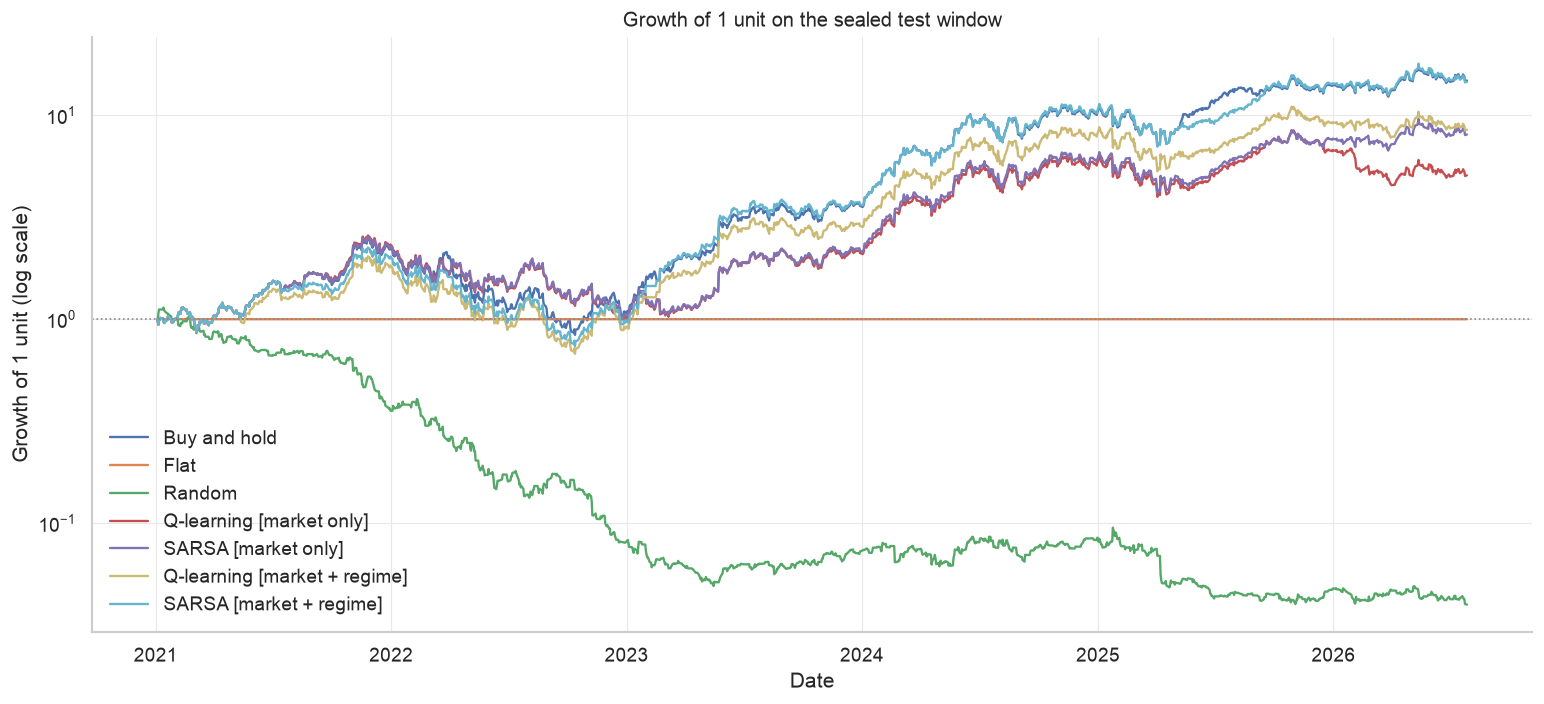

In [36]:
fig = plot_equity_curves(equity_curves(ledgers), "Growth of 1 unit on the sealed test window")
plt.show()
save_figure(fig, "equity_curves", FIG_DIR / "evaluation")

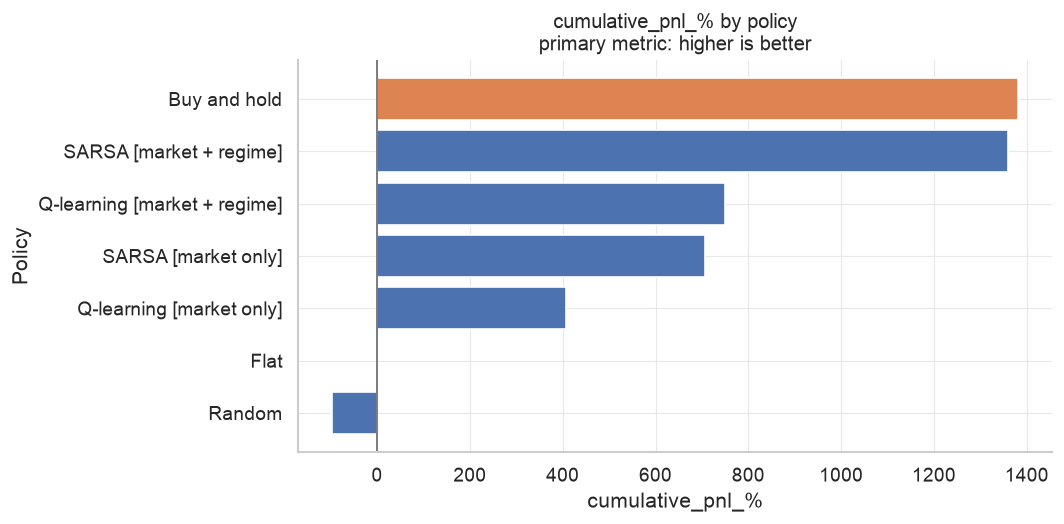

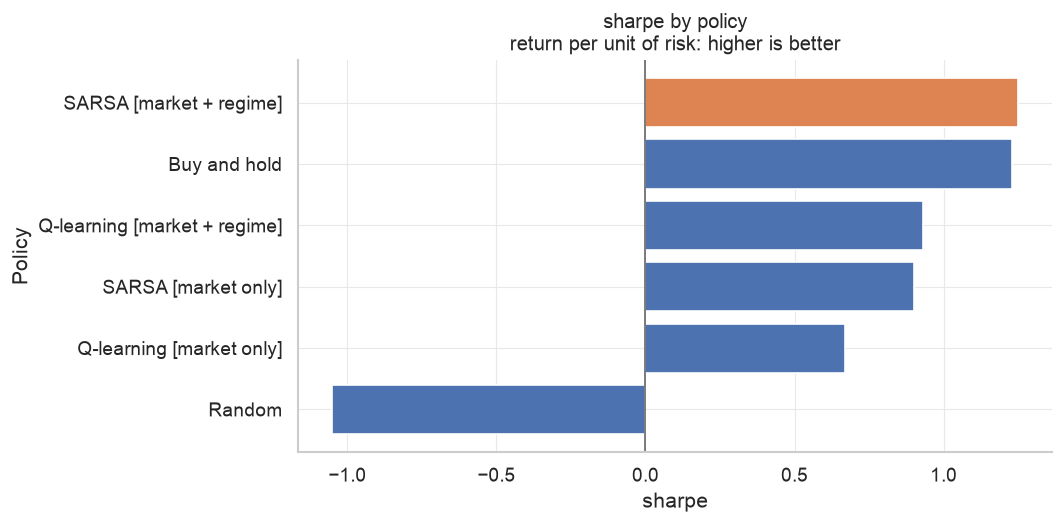

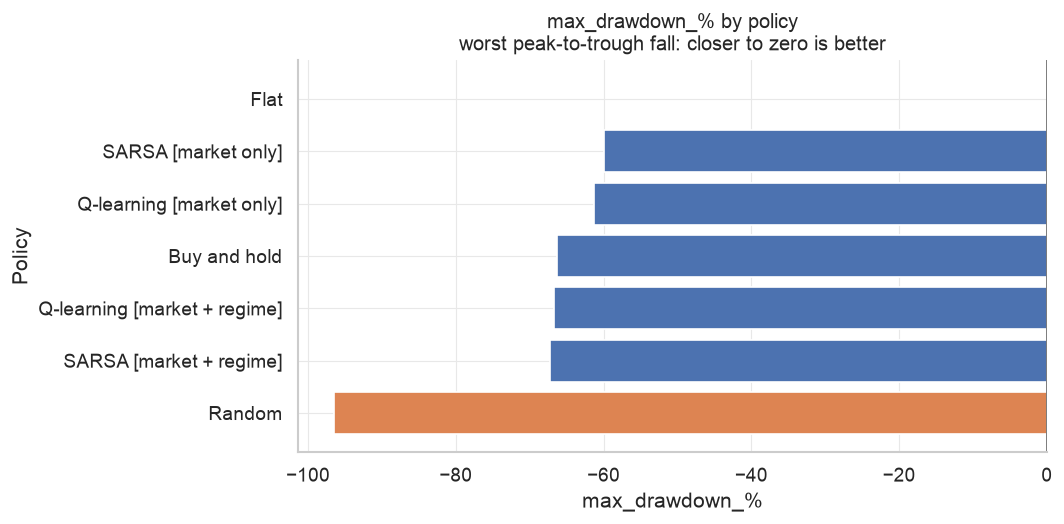

In [37]:
for metric, note in [("cumulative_pnl_%", "primary metric: higher is better"),
                     ("sharpe", "return per unit of risk: higher is better"),
                     ("max_drawdown_%", "worst peak-to-trough fall: closer to zero is better")]:
    fig = plot_metric_comparison(summary, metric, note)
    plt.show()
    save_figure(fig, f"comparison_{metric.strip('%_')}", FIG_DIR / "evaluation")

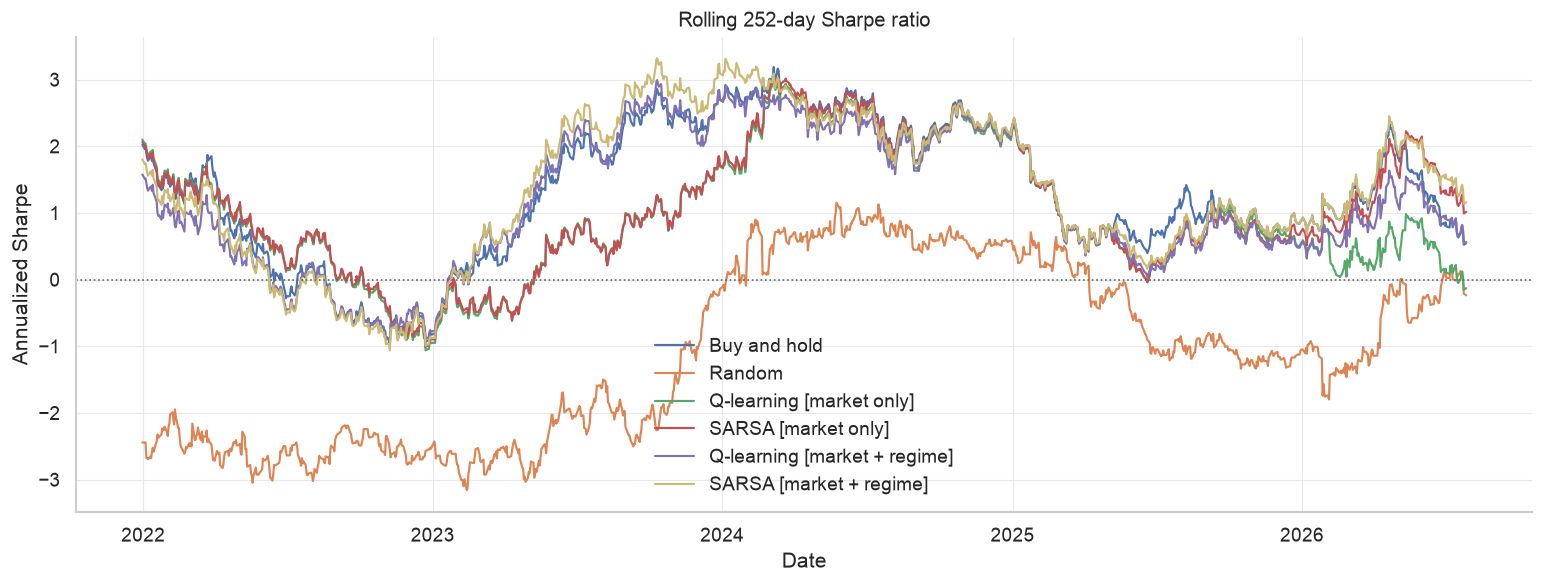

In [38]:
fig = plot_rolling_sharpe({k: v for k, v in ledgers.items() if k != "Flat"})
plt.show()
save_figure(fig, "rolling_sharpe", FIG_DIR / "evaluation")

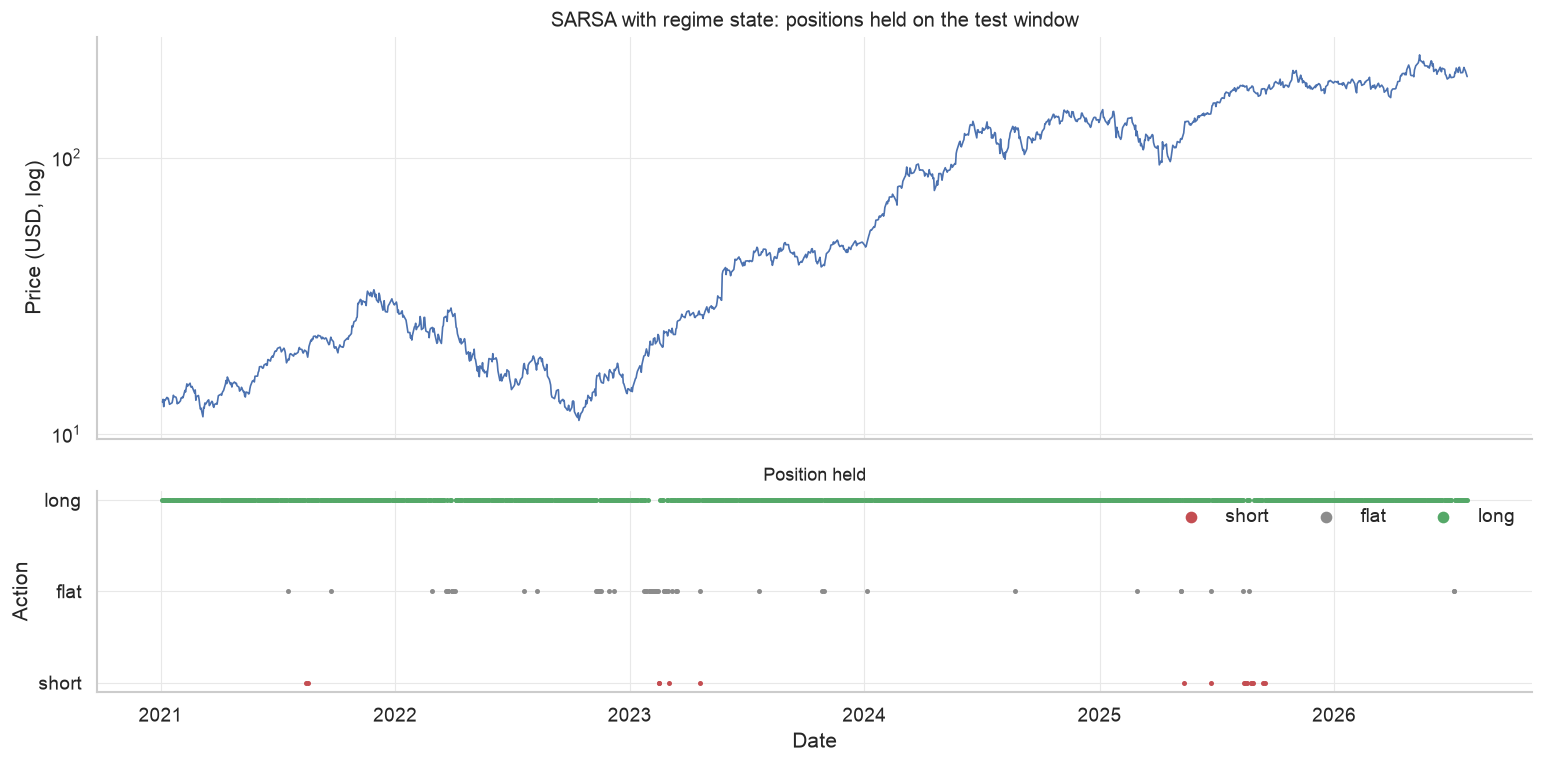

In [39]:
fig = plot_action_timeline(ledgers["SARSA [market + regime]"], test["close"],
                          "SARSA with regime state: positions held on the test window")
plt.show()
save_figure(fig, "action_timeline", FIG_DIR / "rl")

### 10.2 Reading the results honestly

**Against random, the agents win easily.** Random position-taking loses 96% of capital, and the mechanism is worth seeing: it trades 221 units of turnover a year and pays away 123% in cumulative costs. That number alone justifies putting costs in the reward. Without them a coin-flip policy would have looked roughly break-even and every conclusion built on it would be false.

**Against buy-and-hold, it is a tie, not a win.** The best agent, SARSA with the regime state, returns 1360% against 1381%. It edges ahead on Sharpe, 1.25 against 1.23, because it sits out a few of the worst days, but that gap is well inside noise and the drawdowns are effectively identical at about two thirds of capital. Claiming outperformance from a 0.02 Sharpe difference on one asset over one regime would be exactly the overreach this project should avoid.

What the agent did achieve is narrower and defensible: it matched a baseline that is very hard to beat, while holding a position only 96% of the time and trading 16 units of turnover a year. It learned that the right action on this stock is usually to be long, and it learned it from the reward rather than being told.

**The useful comparison is the ablation, not the baseline race.** Buy-and-hold is close to unbeatable on an asset that rose fourteenfold with no shorting opportunity that paid. The question worth asking was whether unsupervised state features improve a policy, and measured under otherwise identical conditions the answer is yes, by roughly double for both algorithms.

**SARSA beats Q-learning in both setups.** The on-policy update values the policy actually being followed, exploration and all, so it converges to something more conservative. Where a wrong position is expensive and the value estimates are drowning in noise, that conservatism is worth more than Q-learning's optimism about a greedy policy it never quite runs.

---
## 11. Conclusion, limitations, and recommendations

### Conclusion

The clustering found three regimes: a melt-up, a calm advance, and a drawdown. They persist, and centroids fitted on 2010 to 2020 still describe 2021 to 2026 correctly.

Adding that one label to the agent's state roughly doubled test PnL for both algorithms, SARSA from 706% to 1360% and Q-learning from 408% to 749%. So the unsupervised layer earned its place.

Against buy-and-hold the best agent tied, 1360% against 1381%, with a Sharpe of 1.25 against 1.23. It did not win. On a stock that rose fourteenfold in five years I did not expect it to.

### Limitations

- One stock, one bull market. Every dip recovered, which flatters anything that stays long.
- The state is coarse. Three bins per feature means the agent cannot see whether volatility is rising or falling.
- In-sample PnL is far above test PnL, so the table is partly memorizing the tape.
- Costs are a flat 10 bps. No slippage, no borrow cost, no market impact.
- Positions are fixed at -1, 0, +1, so the agent cannot size by conviction.

### Recommendations

- Run the same pipeline on a stock that never recovered. That is the real test of the regimes.
- Let the agent size positions instead of choosing from three fixed ones.
- Feed HMM state probabilities instead of hard labels, so boundary days stay uncertain.
- Walk the split forward year by year to turn one test number into a distribution.